# Release Type Classification — Burst vs Sustained

Binary classification: predict whether a formulation is burst release (AUC > 0.5) or sustained release (AUC ≤ 0.5).

AUC is computed using normalised-time trapezoid integration (matching original notebooks).

**Models:** XGBoost, Random Forest, Logistic Regression

**CV:** Drug-level GroupKFold(n=10) — same drug never in both train and test.

**Metrics:** Accuracy, ROC-AUC, Precision, Recall/Sensitivity, Specificity, F1

In [ ]:
!pip install optuna xgboost shap tqdm

In [1]:
import sys
sys.path.insert(0, '.')

from drug_release_pipeline import (
    load_data, make_splits, verify_splits,
    run_class_xgb, run_class_rf, run_class_logistic,
    run_class_xgb_balanced, run_class_rf_balanced, run_class_logistic_balanced,
    compare_class_models, wilcoxon_tests,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import shap
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc

## 1. Load data

In [2]:
FILE_FORM = 'mp_dataset_processed_no_dupes.xlsx'
FILE_TIME = 'mp_dataset_processed_time_release_only.xlsx'

(X, _, _, y_timepoints, y_auc, y_class, _, _, _, aucs,
 drug_groups, _, _, feature_names) = load_data(FILE_FORM, FILE_TIME)

print(f'X shape          : {X.shape}')
print(f'y_class shape    : {y_class.shape}')
print(f'Burst (AUC>0.5)  : {y_class.sum()} ({100*y_class.mean():.1f}%)')
print(f'Sustained        : {(y_class==0).sum()} ({100*(1-y_class.mean()):.1f}%)')
print(f'Feature names    : {feature_names}')

X shape          : (321, 11)
y_class shape    : (321,)
Burst (AUC>0.5)  : 237 (73.8%)
Sustained        : 84 (26.2%)
Feature names    : ['Drug MW', 'Drug TPSA', 'Drug LogP', 'Polymer MW', 'LA/GA', 'Initial Drug-to-Polymer Ratio', 'Particle Size', 'Drug Loading Capacity', 'Drug Encapsulation Efficiency', 'Solubility Enhancer Concentration', 'Formulation Method Encoded']


## 2. Drug-level splits

In [3]:
outer_splits, inner_splits_per_outer = make_splits(drug_groups)
verify_splits(outer_splits, drug_groups)

[verify_splits] OK — 10 folds, 321 formulations, no drug leakage.


## 3. Run models

In [4]:
results_xgb = run_class_xgb(X, y_class, outer_splits, inner_splits_per_outer)


===== XGB-Classification | OUTER FOLD 1/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 14, 'learning_rate': 0.08928657722615006, 'n_estimators': 157, 'subsample': 0.5653333915002821, 'colsample_bytree': 0.9409154722593971, 'gamma': 1.9327337268842064, 'reg_alpha': 0.5138811575365112, 'reg_lambda': 0.47935317739024264}
  ACC=0.8571  ROC-AUC=0.3759  F1=0.9231  Prec=0.8571  Rec=1.0000  Spec=0.0000

===== XGB-Classification | OUTER FOLD 2/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 15, 'learning_rate': 0.026812660390469336, 'n_estimators': 152, 'subsample': 0.5249768131397357, 'colsample_bytree': 0.5928357161137782, 'gamma': 3.0699899388843512, 'reg_alpha': 0.835406538052387, 'reg_lambda': 0.7859021498930013}
  ACC=0.4194  ROC-AUC=0.7668  F1=0.5909  Prec=0.4333  Rec=0.9286  Spec=0.0000

===== XGB-Classification | OUTER FOLD 3/10 =====


...

  Best params: {'max_depth': 19, 'learning_rate': 0.12439043162930032, 'n_estimators': 276, 'subsample': 0.5492339610868966, 'colsample_bytree': 0.9449990048018904, 'gamma': 3.4352587145970084, 'reg_alpha': 0.8106932344198647, 'reg_lambda': 0.8456633405591479}
  ACC=0.8333  ROC-AUC=0.8929  F1=0.9057  Prec=0.9600  Rec=0.8571  Spec=0.5000

===== XGB-Classification | OUTER FOLD 9/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 18, 'learning_rate': 0.011739183057186992, 'n_estimators': 127, 'subsample': 0.5089809378074097, 'colsample_bytree': 0.5072835039169765, 'gamma': 4.538323976412588, 'reg_alpha': 0.9657999152312998, 'reg_lambda': 0.6764178475687505}
  ACC=0.6000  ROC-AUC=0.6713  F1=0.7500  Prec=0.6000  Rec=1.0000  Spec=0.0000

===== XGB-Classification | OUTER FOLD 10/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'max_depth': 20, 'learning_rate': 0.011739183057186992, 'n_estimators': 142, 'subsample': 0.5089809378074097, 'colsample_bytree': 0.6363434386005422, 'gamma': 3.451235367845725, 'reg_alpha': 0.9597707459454197, 'reg_lambda': 0.6765723797427796}
  ACC=0.9000  ROC-AUC=0.8148  F1=0.9474  Prec=0.9000  Rec=1.0000  Spec=0.0000

[XGB-Classification] Accuracy : 0.6951 ± 0.1619
[XGB-Classification] ROC-AUC  : 0.5942 ± 0.1874
[XGB-Classification] F1       : 0.8085 ± 0.1183
[XGB-Classification] Precision: 0.7247 ± 0.1711
[XGB-Classification] Recall   : 0.9445 ± 0.0577
[XGB-Classification] Specificity: 0.0500 ± 0.1500


In [5]:
results_rf = run_class_rf(X, y_class, outer_splits, inner_splits_per_outer)


===== RF-Classification | OUTER FOLD 1/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 178, 'max_depth': 7, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}
  ACC=0.8571  ROC-AUC=0.4575  F1=0.9231  Prec=0.8571  Rec=1.0000  Spec=0.0000

===== RF-Classification | OUTER FOLD 2/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 227, 'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False}
  ACC=0.4516  ROC-AUC=0.6912  F1=0.6222  Prec=0.4516  Rec=1.0000  Spec=0.0000

===== RF-Classification | OUTER FOLD 3/10 =====


...

  Best params: {'n_estimators': 103, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}
  ACC=0.9333  ROC-AUC=0.9643  F1=0.9655  Prec=0.9333  Rec=1.0000  Spec=0.0000

===== RF-Classification | OUTER FOLD 9/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 171, 'max_depth': 6, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}
  ACC=0.6333  ROC-AUC=0.6343  F1=0.7660  Prec=0.6207  Rec=1.0000  Spec=0.0833

===== RF-Classification | OUTER FOLD 10/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'n_estimators': 221, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}
  ACC=0.9000  ROC-AUC=0.8025  F1=0.9474  Prec=0.9000  Rec=1.0000  Spec=0.0000

[RF-Classification] Accuracy : 0.7181 ± 0.1627
[RF-Classification] ROC-AUC  : 0.6219 ± 0.1505
[RF-Classification] F1       : 0.8230 ± 0.1151
[RF-Classification] Precision: 0.7289 ± 0.1590
[RF-Classification] Recall   : 0.9712 ± 0.0574
[RF-Classification] Specificity: 0.0160 ± 0.0321


In [8]:
results_lr = run_class_logistic(X, y_class, outer_splits, inner_splits_per_outer)


===== Logistic-Classification | OUTER FOLD 1/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'C': 0.11327750227759759, 'penalty': 'l1', 'max_iter': 692, 'tol': 4.363650979727527e-06, 'class_weight': None}
  ACC=0.8367  ROC-AUC=0.6650  F1=0.9111  Prec=0.8542  Rec=0.9762  Spec=0.0000

===== Logistic-Classification | OUTER FOLD 2/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'C': 0.04045656647323129, 'penalty': 'l1', 'max_iter': 814, 'tol': 4.4412796733158895e-06, 'class_weight': None}
  ACC=0.4516  ROC-AUC=0.7227  F1=0.6222  Prec=0.4516  Rec=1.0000  Spec=0.0000

===== Logistic-Classification | OUTER FOLD 3/10 =====


...

  Best params: {'C': 0.04045656647323129, 'penalty': 'l1', 'max_iter': 814, 'tol': 4.4412796733158895e-06, 'class_weight': None}
  ACC=0.9333  ROC-AUC=0.9286  F1=0.9655  Prec=0.9333  Rec=1.0000  Spec=0.0000

===== Logistic-Classification | OUTER FOLD 9/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'C': 0.05868768546842992, 'penalty': 'l1', 'max_iter': 834, 'tol': 4.12703743652158e-06, 'class_weight': None}
  ACC=0.6000  ROC-AUC=0.7639  F1=0.7500  Prec=0.6000  Rec=1.0000  Spec=0.0000

===== Logistic-Classification | OUTER FOLD 10/10 =====


  Optuna trials:   0%|          | 0/50 [00:00<?, ?trial/s]

  Best params: {'C': 0.0009021232941397158, 'penalty': 'l2', 'max_iter': 508, 'tol': 0.0007864978751369729, 'class_weight': None}
  ACC=0.7333  ROC-AUC=0.5556  F1=0.8400  Prec=0.9130  Rec=0.7778  Spec=0.3333

[Logistic-Classification] Accuracy : 0.7060 ± 0.1543
[Logistic-Classification] ROC-AUC  : 0.6204 ± 0.1620
[Logistic-Classification] F1       : 0.8165 ± 0.1090
[Logistic-Classification] Precision: 0.7310 ± 0.1635
[Logistic-Classification] Recall   : 0.9595 ± 0.0694
[Logistic-Classification] Specificity: 0.0444 ± 0.1018


## 4. Compare models

In [9]:
all_results = {
    'XGB'      : results_xgb,
    'RF'       : results_rf,
    'Logistic' : results_lr,
}

df_metrics = compare_class_models(all_results)


=== Classification Model Comparison ===
          accuracy             roc_auc           precision              recall           specificity                  f1          
              mean       std      mean       std      mean       std      mean       std        mean       std      mean       std
model                                                                                                                             
Logistic  0.706039  0.162671  0.620351  0.170808  0.730991  0.172312  0.959524  0.073166    0.044444  0.107344  0.816509  0.114930
RF        0.718080  0.171459  0.621928  0.158608  0.728883  0.167647  0.971224  0.060498    0.016026  0.033819  0.823003  0.121340
XGB       0.695069  0.170636  0.594222  0.197535  0.724741  0.180332  0.944484  0.060850    0.050000  0.158114  0.808468  0.124696


## 5. Wilcoxon tests

In [10]:
wilcoxon_tests(all_results, metric='accuracy')
wilcoxon_tests(all_results, metric='roc_auc')
wilcoxon_tests(all_results, metric='f1')


=== Wilcoxon tests on accuracy ===
  XGB vs RF: W=7.0, p=0.2350  ns
  XGB vs Logistic: W=9.0, p=0.2053  ns
  RF vs Logistic: W=7.5, p=0.5282  ns

=== Wilcoxon tests on roc_auc ===
  XGB vs RF: W=22.0, p=0.6250  ns
  XGB vs Logistic: W=23.0, p=0.6953  ns
  RF vs Logistic: W=27.0, p=1.0000  ns

=== Wilcoxon tests on f1 ===
  XGB vs RF: W=7.0, p=0.2367  ns
  XGB vs Logistic: W=12.0, p=0.2135  ns
  RF vs Logistic: W=12.0, p=0.7353  ns


## 6. Per-fold metrics boxplot

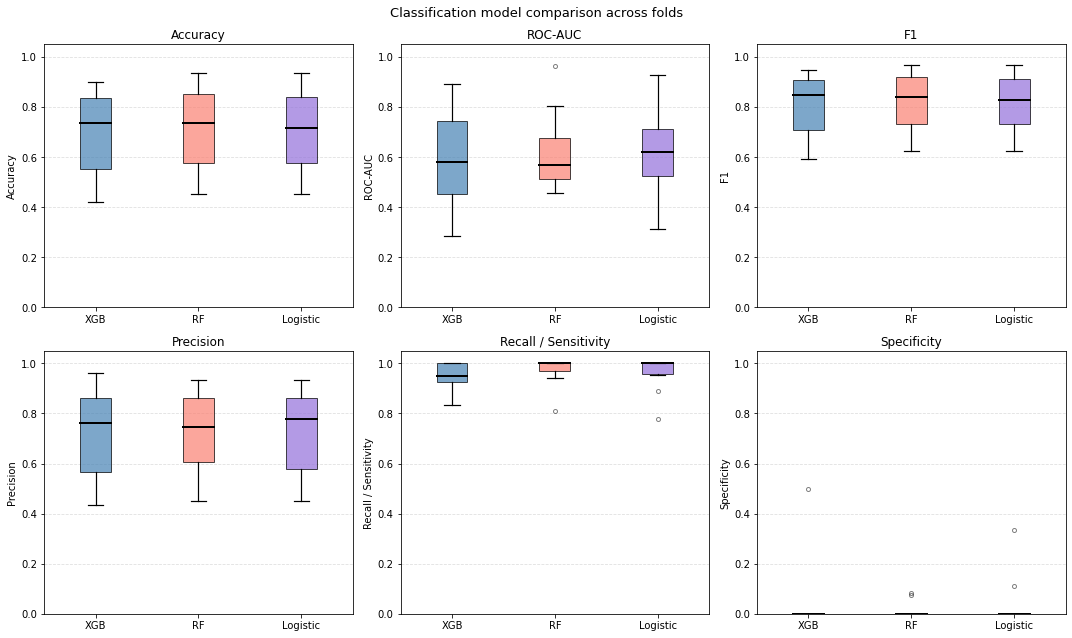

In [11]:
names        = list(all_results.keys())
colors       = ['steelblue', 'salmon', 'mediumpurple']
metrics_plot = ['accuracy', 'roc_auc', 'f1', 'precision', 'recall', 'specificity']
titles       = ['Accuracy', 'ROC-AUC', 'F1', 'Precision', 'Recall / Sensitivity', 'Specificity']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, metric, title in zip(axes, metrics_plot, titles):
    data = [all_results[n][metric] for n in names]
    bp   = ax.boxplot(data, patch_artist=True,
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(linewidth=1.2),
                      capprops=dict(linewidth=1.2),
                      flierprops=dict(marker='o', markersize=4, alpha=0.5))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(names) + 1))
    ax.set_xticklabels(names, fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(title, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Classification model comparison across folds', fontsize=13)
plt.tight_layout()
plt.savefig('class_models_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Confusion matrices

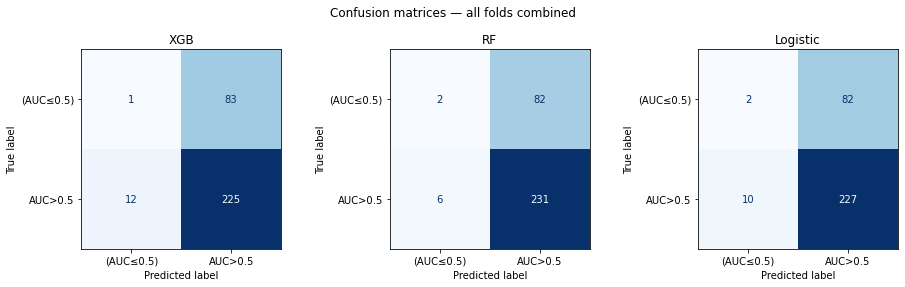

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, res) in zip(axes, all_results.items()):
    all_preds   = np.concatenate(res['preds'])
    all_targets = np.concatenate(res['targets'])
    cm = confusion_matrix(all_targets, all_preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['(AUC≤0.5)', 'AUC>0.5']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion matrices — all folds combined', fontsize=12)
plt.tight_layout()
plt.savefig('class_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. ROC curves

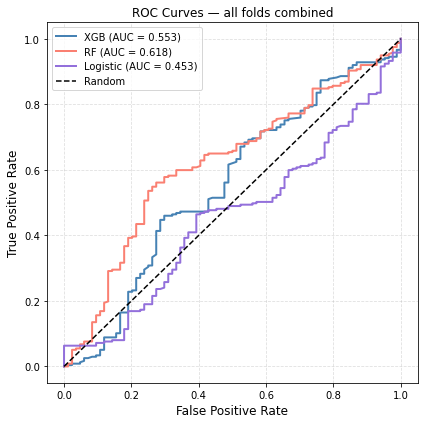

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
colors_roc = ['steelblue', 'salmon', 'mediumpurple']

for (name, res), color in zip(all_results.items(), colors_roc):
    all_proba   = np.concatenate(res['proba'])
    all_targets = np.concatenate(res['targets'])
    fpr, tpr, _ = roc_curve(all_targets, all_proba)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — all folds combined', fontsize=12)
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('class_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. SHAP — XGBoost

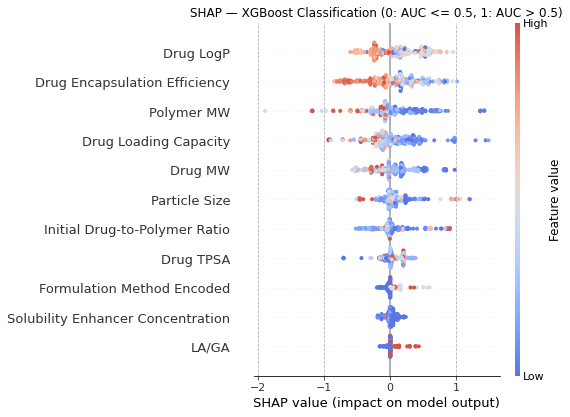

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Modern approach (matplotlib >= 3.7)
base_cmap = mpl.colormaps['coolwarm']

# OR if you need broader compatibility
base_cmap = plt.get_cmap('coolwarm')

#base_cmap  = cm.get_cmap('coolwarm')
light_cmap = LinearSegmentedColormap.from_list(
    'light_coolwarm', base_cmap(np.linspace(0.1, 0.9, 256))
)

combined_shap_xgb = np.concatenate(
    [sv for sv in results_xgb['shap_values'] if sv is not None], axis=0
)
combined_X_xgb = np.concatenate(results_xgb['shap_X_test'], axis=0)

plt.figure()
shap.summary_plot(combined_shap_xgb, combined_X_xgb,
                  feature_names=feature_names, plot_type='dot',
                  cmap=light_cmap, show=False)
ax = plt.gca()
ax.grid(True, which='both', axis='x', linestyle='--')
ax.set_axisbelow(True)
plt.title('SHAP — XGBoost Classification (0: AUC <= 0.5, 1: AUC > 0.5)', fontsize=12)
plt.tight_layout()
#plt.savefig('shap_xgb_classification.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. SHAP — Random Forest

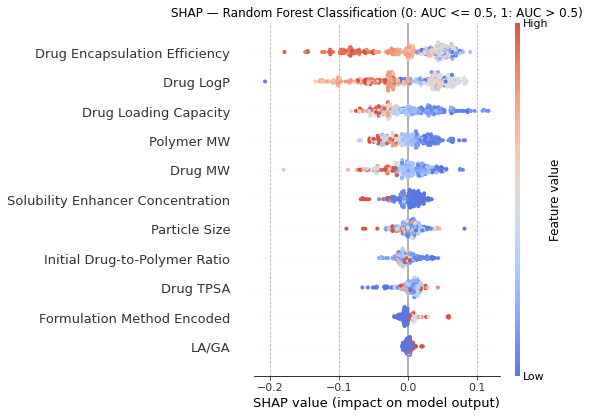

In [15]:
combined_shap_rf = np.concatenate(
    [sv for sv in results_rf['shap_values'] if sv is not None], axis=0
)
combined_X_rf = np.concatenate(results_rf['shap_X_test'], axis=0)

plt.figure()
shap.summary_plot(combined_shap_rf, combined_X_rf,
                  feature_names=feature_names, plot_type='dot',
                  cmap=light_cmap, show=False)
ax = plt.gca()
ax.grid(True, which='both', axis='x', linestyle='--')
ax.set_axisbelow(True)
plt.title('SHAP — Random Forest Classification (0: AUC <= 0.5, 1: AUC > 0.5)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_rf_classification.png', dpi=300, bbox_inches='tight')
plt.show()

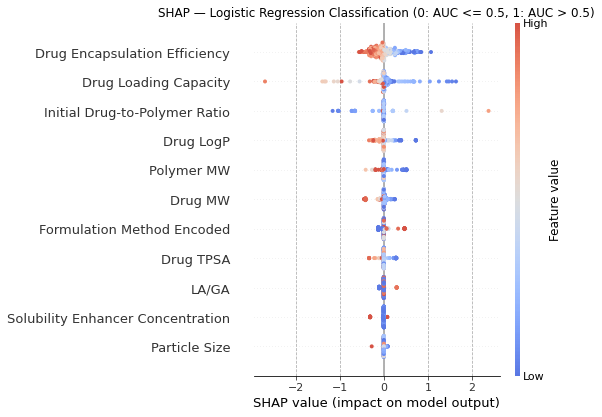

In [17]:
combined_shap_lr = np.concatenate(
    [sv for sv in results_lr['shap_values'] if sv is not None], axis=0
)
combined_X_lr = np.concatenate(results_lr['shap_X_test'], axis=0)

plt.figure()
shap.summary_plot(combined_shap_lr, combined_X_lr,
                  feature_names=feature_names, plot_type='dot',
                  cmap=light_cmap, show=False)
ax = plt.gca()
ax.grid(True, which='both', axis='x', linestyle='--')
ax.set_axisbelow(True)
plt.title('SHAP — Logistic Regression Classification (0: AUC <= 0.5, 1: AUC > 0.5)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_lr_classification.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Save results

In [18]:
df_metrics.to_csv('classification_metrics.csv', index=False)

for name, res in all_results.items():
    rows = []
    for fold_i, (preds, proba, targets) in enumerate(
        zip(res['preds'], res['proba'], res['targets']), 1
    ):
        for p, pr, t in zip(preds, proba, targets):
            rows.append({'model': name, 'fold': fold_i,
                         'y_pred': p, 'y_proba': pr, 'y_true': t})
    pd.DataFrame(rows).to_csv(f'{name}_classification_preds.csv', index=False)

print('Saved classification_metrics.csv and per-model prediction CSVs.')

Saved classification_metrics.csv and per-model prediction CSVs.
